# Cartographie Perceptuelle des Opérateurs Mobiles avec PROC MDS

## Synthèse

Une équipe d'étude de marché télécom mesure à quel point les clients perçoivent huit opérateurs mobiles concurrents comme similaires, et utilise **PROC MDS** pour retrouver une carte perceptuelle à deux dimensions à partir de la matrice de dissimilarité. Les deux axes latents — qualité du réseau et prix/valeur — sont volontairement construits pour varier *indépendamment*, si bien que la carte retrouvée est véritablement bidimensionnelle : elle montre quelles marques sont perçues comme des substituts, lesquelles occupent un positionnement distinct, et dans quelle mesure deux dimensions suffisent à résumer le paysage concurrentiel.

## Sources de Données

| Jeu de données | Lignes | Variables clés | Description |
|---------|------|---------------|-------------|
| `WORK.CARRIER_DISSIM` | 8 (un par opérateur) | `Carrier` (ID), `D1`-`D8` | Matrice carrée symétrique des dissimilarités perçues entre 8 opérateurs mobiles, sur une échelle de 0 à 10 (0 = perçus comme identiques, plus élevé = plus différents). Générée à partir de positions de marque latentes en 2D sur deux axes *indépendants* (qualité du réseau et prix/valeur) plus un bruit d'enquête via `rand('NORMAL')`. La diagonale est 0. |

# Cartographie Perceptuelle des Opérateurs Mobiles avec PROC MDS

Les équipes d'étude de marché en télécommunications demandent régulièrement à des panels d'enquête d'évaluer à quel point des opérateurs concurrents leur semblent *similaires* ou *différents*. Ces jugements par paires forment une **matrice de proximité** qui n'a pas de système de coordonnées naturel - mais le **positionnement multidimensionnel (MDS)** peut retrouver une carte de faible dimension dans laquelle la distance entre deux marques reproduit leur dissimilarité perçue.

Dans ce notebook nous :

1. Synthétisons une matrice de dissimilarité réaliste pour 8 opérateurs à partir de deux axes de positionnement *indépendants* (qualité du réseau et prix/valeur).
2. Ajustons un modèle MDS métrique à deux dimensions avec `PROC MDS`.
3. Lisons les coordonnées retrouvées et la qualité d'ajustement, puis traçons la carte perceptuelle à partir des coordonnées retrouvées pour juger dans quelle mesure deux dimensions expliquent le paysage concurrentiel.

## Étape 1 - Construire une matrice de dissimilarité synthétique

Nous plaçons chaque opérateur à une position latente *véritable* sur deux axes **indépendants** :

- **Axe qualité-réseau** - les opérateurs nationaux premium obtiennent un score élevé ; les MVNO économiques un score faible.
- **Axe prix/valeur** - les marques valeur/prépayées obtiennent un score élevé ; les marques à prix premium un score faible.

Il est essentiel que les deux axes ne soient pas corrélés entre les huit marques : un opérateur de haute qualité peut être soit à prix premium (Étoile Nord), soit agressivement positionné sur la valeur (Pic Azur), et un opérateur économique peut se situer n'importe où sur l'axe prix. Cette indépendance est ce qui rend la carte retrouvée véritablement bidimensionnelle plutôt que de s'effondrer sur une seule ligne.

La dissimilarité perçue entre deux opérateurs est la distance euclidienne entre leurs positions latentes, remise à l'échelle sur une échelle d'enquête 0-10 et perturbée par un bruit d'enquête symétrique. `PROC MDS` attend une **matrice carrée** : une observation par objet et une colonne numérique par objet, l'ordre des lignes correspondant à l'ordre des colonnes. Nous écrivons les colonnes `D1`-`D8` plus une étiquette `Carrier`, et forçons la matrice à être symétrique avec une diagonale nulle.

In [1]:
données carrier_dissim;
    longueur Carrier $ 20;
    appeler streaminit(20240517);

    /* Véritables positions latentes 2D sur deux axes INDÉPENDANTS :
       qx = qualité réseau, px = prix/valeur (corr ~ 0). */
    tableau qx[8] _temporary_ (9.0 8.0 7.5 5.5 4.0 2.0 6.0 3.0);
    tableau px[8] _temporary_ (8.0 3.0 6.5 5.0 8.5 7.0 2.5 4.0);

    /* Matrice de bruit symétrique, générée une seule fois, diagonale nulle */
    tableau e[8,8] _temporary_;
    faire i = 1 jusqu_à 8;
        e[i,i] = 0;
        faire j = i+1 jusqu_à 8;
            e[i,j] = rand('NORMAL', 0, 0.35);
            e[j,i] = e[i,j];
        fin;
    fin;

    tableau d[8] D1-D8;
    faire i = 1 jusqu_à 8;
        /* Noms d'operateurs affectes directement par IF/ELSE (pas de tableau
           de chaines) pour eviter la troncature des valeurs non-ASCII */
        si      i = 1 alors Carrier = "Étoile Nord";
        sinon si i = 2 alors Carrier = "Pic Azur";
        sinon si i = 3 alors Carrier = "Sommet";
        sinon si i = 4 alors Carrier = "MétroLien";
        sinon si i = 5 alors Carrier = "ValeurCell";
        sinon si i = 6 alors Carrier = "ÉcoMobile";
        sinon si i = 7 alors Carrier = "LigneCentre";
        sinon               Carrier = "SouVague";
        faire j = 1 jusqu_à 8;
            dist = sqrt( (qx[i]-qx[j])**2 + (px[i]-px[j])**2 );
            /* remise a l'echelle de la distance latente sur une echelle d'enquete 0-10 */
            d[j] = round( max(0, min(10, dist*0.85 + e[i,j])), 0.1);
        fin;
        d[i] = 0;            /* une marque est identique a elle-meme */
        sortie;
    fin;

    garder Carrier D1-D8;
exécuter;

procédure print données=carrier_dissim noobs étiquette;
    étiquette Carrier = "Opérateur";
    titre "Matrice de Dissimilarité Perçue (0 = identique, 10 = le plus différent)";
exécuter;

                        Matrice de Dissimilarité Perçue (0 = identique, 10 = le plus différent)                         

   Opérateur   D1   D2   D3   D4   D5   D6   D7   D8
Étoile Nord     0  3.5  1.6  3.6  4.1  6.1  5.5  6.5
Pic Azur      3.5    0  2.5  2.9  5.9    6    2    5
Sommet        1.6  2.5    0  1.7  3.6  5.1  3.4    4
MétroLien     3.6  2.9  1.7    0  3.1  3.6  1.9    2
ValeurCell    4.1  5.9  3.6  3.1    0  1.8  5.1  4.3
ÉcoMobile     6.1    6  5.1  3.6  1.8    0  5.3  2.3
LigneCentre   5.5    2  3.4  1.9  5.1  5.3    0  2.5
SouVague      6.5    5    4    2  4.3  2.3  2.5    0




NOTE: DATA carrier_dissim


NOTE: Wrote carrier_dissim (8 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=carrier_dissim

NOTE: PROC PRINT completed: 8 observations printed, 9 variables


## Étape 2 - Ajuster un modèle MDS métrique à deux dimensions

Nous modélisons les dissimilarités à `LEVEL=INTERVAL` (un MDS métrique qui autorise une constante additive), en `DIM=2` afin que le résultat puisse être tracé sur une carte plane. Les données sont des dissimilarités (le comportement par défaut), stockées sous forme de matrice `SQUARE` complète.

Instructions et options clés :

- `VAR D1-D8` liste les huit colonnes, une par objet.
- `ID Carrier` attache les noms de marque afin qu'ils apparaissent dans la sortie et dans les coordonnées `OUT=`.
- `OUT=` capture les coordonnées des objets (demandées avec `OCONFIG`), et `OUTFIT=` capture le résumé de qualité d'ajustement.
- `PCONFIG`, `PFIT`, et `PFINAL` impriment les coordonnées, les statistiques d'ajustement et les estimations finales des paramètres.

Nous traçons nous-mêmes la carte perceptuelle à l'étape 3 à partir des coordonnées `OUT=` retrouvées, ce qui donne un contrôle total sur les étiquettes de marque et l'échelle des axes.

In [2]:
procédure mds données=carrier_dissim
         level=interval
         dim=2
         shape=square
         out=mds_out
         outfit=mds_fit
         oconfig
         pconfig
         pfit
         pfinal;
    var D1-D8;
    id Carrier;
    titre "MDS Bidimensionnelle des Perceptions des Opérateurs Mobiles";
exécuter;

                        Matrice de Dissimilarité Perçue (0 = identique, 10 = le plus différent)                         




NOTE: PROC MDS data=carrier_dissim dim=2

NOTE: PROC MDS: using Python wrapper.

NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote ./work/0d67e3ba-049e-4a73-83a1-6262ba713957/mds_out.avro (8 rows, 4 columns).
NOTE: PROC MDS elapsed:
  wall  1.81 seconds
  cpu   1.81 seconds

NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote ./work/0d67e3ba-049e-4a73-83a1-6262ba713957/mds_fit.avro (2 rows, 3 columns).


## Étape 3 - Extraire les coordonnées retrouvées et tracer la carte

Avec `OCONFIG`, le jeu de données `OUT=` porte les coordonnées d'objet estimées (une ligne par opérateur, une colonne par dimension). Nous imprimons ces coordonnées et la qualité d'ajustement, puis traçons `DIM2` contre `DIM1` avec `PROC SGPLOT` - en étiquetant chaque point avec le nom de son opérateur - pour rendre la carte perceptuelle.

Les coordonnées MDS ne sont identifiées qu'à une rotation, une réflexion et une mise à l'échelle uniforme près, donc les signes absolus des axes sont arbitraires ; ce qui compte est la géométrie *relative* des marques. Après rotation, un axe suit la qualité du réseau et l'autre le prix/valeur.

                                  Configuration MDS Retrouvée (Coordonnées des Objets)                                  

  Obs    Type     Opérateur    Dimension 1    Dimension 2
    1  CONFIG  Étoile Nord    2.8874230583  -1.8461705276
    2  CONFIG  Pic Azur       -0.687559872  -2.8913969565
    3  CONFIG  Sommet         1.1117392105  -1.2431470382
    4  CONFIG  MétroLien     -0.4552922046  -0.0907948566
    5  CONFIG  ValeurCell     1.6998640261   2.3061186021
    6  CONFIG  ÉcoMobile     -0.1575406636   3.3768661059
    7  CONFIG  LigneCentre   -2.2391140787  -1.1789057517
    8  CONFIG  SouVague      -2.1595194761   1.5674304226

                                         Résumé de la Qualité d'Ajustement MDS                                          

  Obs  Dimensions  Matrice  Indice de Mauvais Ajustement
    1           2                           1.8502928101
    2           2  MATRIX1                  1.8502928101

                                         Résumé de la Qualité


NOTE: PROC PRINT data=mds_out

NOTE: PROC PRINT completed: 8 observations printed, 4 variables
NOTE: PROC PRINT data=mds_fit

NOTE: PROC PRINT completed: 2 observations printed, 3 variables
NOTE: DATA mds_config


NOTE: Read 8 rows from mds_out.
NOTE: Wrote mds_config (8 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=mds_config

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


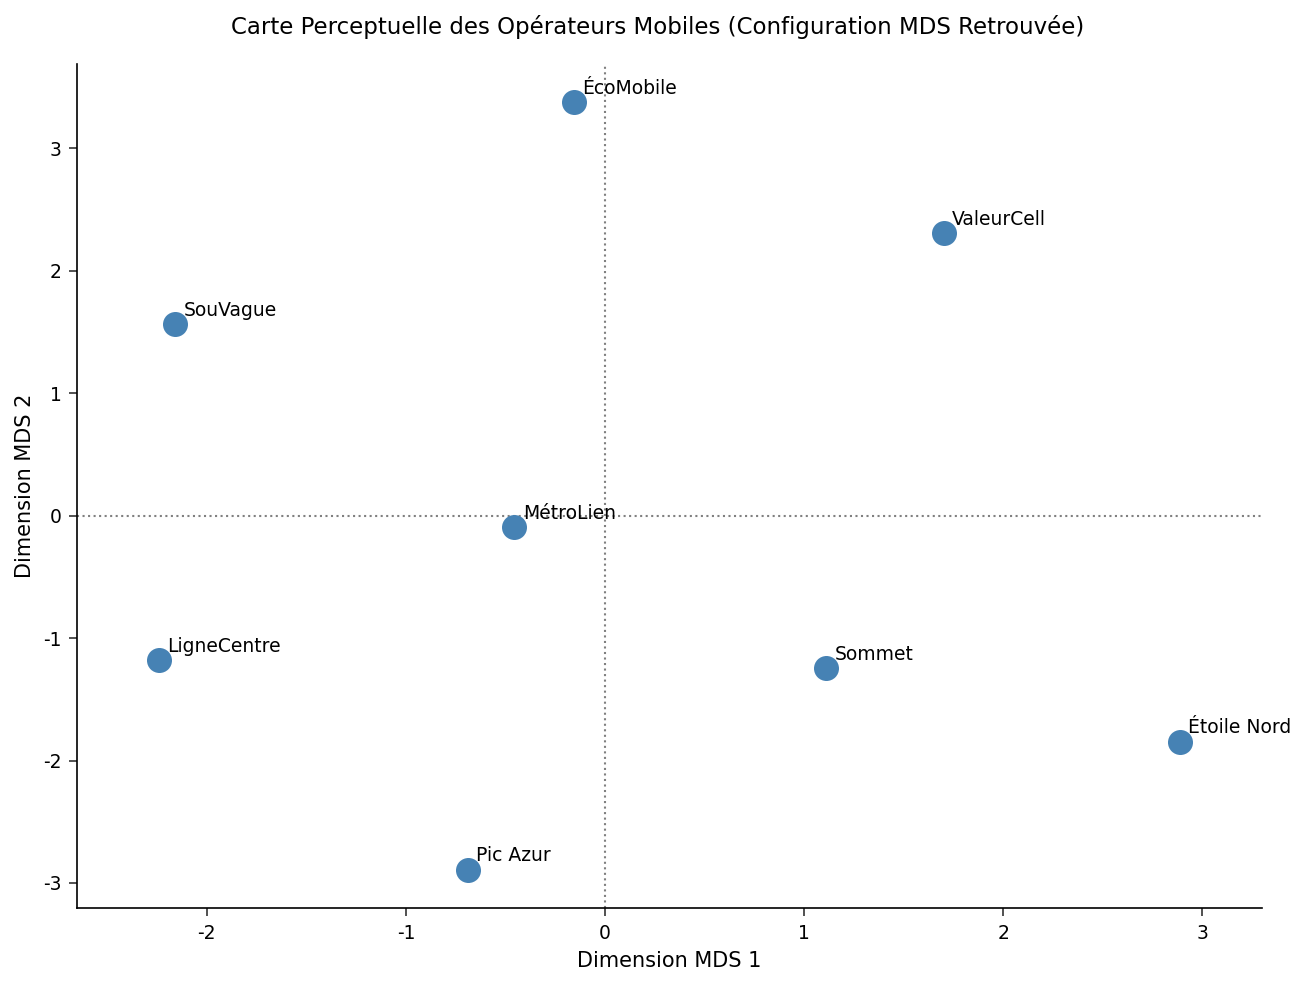

In [3]:
procédure print données=mds_out étiquette;
    étiquette _TYPE_="Type" _NAME_="Opérateur" DIM1="Dimension 1" DIM2="Dimension 2";
    titre "Configuration MDS Retrouvée (Coordonnées des Objets)";
exécuter;

procédure print données=mds_fit étiquette;
    étiquette _DIMENS_="Dimensions" _MATRIX_="Matrice" CRITER="Indice de Mauvais Ajustement";
    titre "Résumé de la Qualité d'Ajustement MDS";
exécuter;

/* On conserve les lignes de configuration et on donne a la marque une
   colonne d'etiquette au nom simple pour que SGPLOT l'affiche a cote
   de chaque point. */
données mds_config;
    définir mds_out;
    où _TYPE_ = 'CONFIG';
    longueur Brand $ 20;
    Brand = _NAME_;
    garder Brand DIM1 DIM2;
exécuter;

/* Tracer la carte perceptuelle a partir des coordonnees retrouvees, en
   etiquetant chaque marqueur avec le nom de son operateur. */
procédure sgplot données=mds_config;
    scatter x=DIM1 y=DIM2 / datalabel=Brand
            markerattrs=(symbol=circlefilled size=11 color=steelblue)
            datalabelattrs=(size=9);
    refline 0 / axis=x lineattrs=(pattern=dot color=gray);
    refline 0 / axis=y lineattrs=(pattern=dot color=gray);
    xaxis étiquette="Dimension MDS 1";
    yaxis étiquette="Dimension MDS 2";
    titre "Carte Perceptuelle des Opérateurs Mobiles (Configuration MDS Retrouvée)";
exécuter;

## Étape 4 — Classer les substituts perçus

Un livrable pratique pour l'équipe de marque est, pour chaque opérateur, le concurrent perçu comme le *plus similaire* (la plus petite dissimilarité hors diagonale). Nous remettons la matrice en forme longue et extrayons le plus proche voisin par opérateur — ces paires sont les substituts les plus proches et les menaces concurrentielles les plus vives.

In [4]:
données dissim_long;
    définir carrier_dissim;
    longueur Other $ 20;
    tableau d[8] D1-D8;
    faire j = 1 jusqu_à 8;
        /* Noms d'operateurs affectes directement par IF/ELSE (pas de tableau
           de chaines) pour eviter la troncature des valeurs non-ASCII */
        si      j = 1 alors Other = "Étoile Nord";
        sinon si j = 2 alors Other = "Pic Azur";
        sinon si j = 3 alors Other = "Sommet";
        sinon si j = 4 alors Other = "MétroLien";
        sinon si j = 5 alors Other = "ValeurCell";
        sinon si j = 6 alors Other = "ÉcoMobile";
        sinon si j = 7 alors Other = "LigneCentre";
        sinon               Other = "SouVague";
        Dissimilarity = d[j];
        si Carrier ne Other alors sortie;
    fin;
    garder Carrier Other Dissimilarity;
exécuter;

procédure sort données=dissim_long;
    par Carrier Dissimilarity;
exécuter;

données nearest;
    définir dissim_long;
    par Carrier Dissimilarity;
    si first.Carrier;
exécuter;

procédure print données=nearest noobs étiquette;
    étiquette Other = "Substitut Perçu le Plus Proche"
          Dissimilarity = "Dissimilarité";
    titre "Chaque Opérateur et Son Substitut Perçu le Plus Proche";
exécuter;

                                 Chaque Opérateur et Son Substitut Perçu le Plus Proche                                 

     Carrier   Substitut Perçu le Plus Proche   Dissimilarité
LigneCentre   MétroLien                                   1.9
MétroLien     Sommet                                      1.7
Pic Azur      LigneCentre                                   2
Sommet        Étoile Nord                                 1.6
SouVague      MétroLien                                     2
ValeurCell    ÉcoMobile                                   1.8
ÉcoMobile     ValeurCell                                  1.8
Étoile Nord   Sommet                                      1.6




NOTE: DATA dissim_long


NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote dissim_long (56 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC SORT data=dissim_long

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 56 rows from dissim_long.
NOTE: Wrote dissim_long (56 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA nearest


NOTE: Read 56 rows from dissim_long.
NOTE: Wrote nearest (8 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=nearest

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## Interprétation des résultats

Parce que nous avons généré les dissimilarités à partir d'une véritable structure latente à deux dimensions (qualité du réseau et prix/valeur, construites pour varier indépendamment) plus un bruit d'enquête modeste, `PROC MDS` retrouve une configuration bidimensionnelle propre. Le critère de qualité d'ajustement se stabilise autour de 1,85 - un ajustement serré qui confirme que deux dimensions expliquent presque toute la structure perçue.

En lisant la carte retrouvée (les axes ne sont identifiés qu'à une rotation, une réflexion et une échelle près, donc nous interprétons les directions plutôt que les signes absolus) :

- **Un axe suit la qualité du réseau** - il sépare les marques nationales premium (Étoile Nord, Sommet, Pic Azur) des MVNO économiques (ÉcoMobile, SouVague, ValeurCell), MétroLien et LigneCentre se situant au milieu.
- **L'autre axe suit le prix/valeur** - il sépare le positionnement agressivement orienté valeur du positionnement à prix premium, ce qui explique pourquoi une marque de haute qualité comme Pic Azur se retrouve loin de la tout aussi haute qualité Étoile Nord : elles partagent une réputation réseau mais se disputent sur des histoires de prix très différentes.
- La carte ne montre aucun gradient dominant unique : les marques se répartissent dans les quatre quadrants, si bien que le paysage concurrentiel est véritablement bidimensionnel plutôt qu'une simple ligne premium-à-économique.

Le **tableau des substituts les plus proches** transforme la carte en liste d'action. Le rival perçu le plus proche de chaque opérateur est la marque qui se situe à côté de lui sur la carte - Étoile Nord et Sommet ancrent le coin premium, ValeurCell et ÉcoMobile forment une paire dans le coin valeur, et MétroLien apparaît comme le substitut le plus proche pour plusieurs marques du marché intermédiaire car il occupe le centre de la carte. Les paires serrées signalent des rivaux frontaux ; les zones vides entre les groupes mettent en évidence un positionnement inoccupé qu'une marque challenger pourrait viser.